In [19]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

In [20]:
import random

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    
set_seed(42)

In [21]:
if torch.cuda.is_available():
    device = 'cuda'
else:
    device = 'cpu'

device

'cuda'

In [22]:
df = pd.read_csv('Bhairawa_lag5year.csv')
df.head()

,DateTime,temp,hour,minute,dayofweek,dayofyear,month,year,slot,slot_sin,...,dow_sin,dow_cos,doy_sin,doy_cos,lag_1day,lag_2day,lag_3day,lag_7day,season,year_index
0,2021-01-08 00:00:00,15.49,0,0,4,8,1,2021,0,0.000000,...,-0.433884,-0.900969,0.137279,0.990532,17.85,18.78,17.52,14.41,0,0
1,2021-01-08 00:15:00,15.49,0,15,4,8,1,2021,1,0.065403,...,-0.433884,-0.900969,0.137279,0.990532,17.85,18.78,17.52,14.41,0,0
2,2021-01-08 00:30:00,15.49,0,30,4,8,1,2021,2,0.130526,...,-0.433884,-0.900969,0.137279,0.990532,17.85,18.78,17.52,14.41,0,0
3,2021-01-08 00:45:00,15.49,0,45,4,8,1,2021,3,0.195090,...,-0.433884,-0.900969,0.137279,0.990532,17.85,18.78,17.52,14.41,0,0
4,2021-01-08 01:00:00,15.44,1,0,4,8,1,2021,4,0.258819,...,-0.433884,-0.900969,0.137279,0.990532,17.64,19.24,17.45,14.37,0,0


In [23]:
#Test Train Split
X = df.iloc[:, 2:].values
y = df.iloc[:, 1].values

In [24]:
X.shape

(175104, 19)

In [25]:
y.shape

(175104,)

In [26]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=False)

In [27]:
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_train = scaler_X.fit_transform(X_train)
X_test  = scaler_X.transform(X_test)
y_train = scaler_y.fit_transform(y_train.reshape(-1,1))
y_test  = scaler_y.transform(y_test.reshape(-1,1))

In [28]:
# convert numpy arrays to PyTorch Tensors
X_train_tensor = torch.from_numpy(X_train).float()
X_test_tensor = torch.from_numpy(X_test).float()
y_train_tensor = torch.from_numpy(y_train).float()
y_test_tensor = torch.from_numpy(y_test).float()

Creating Dataset and Dataloader Class

In [29]:
class CustomDataset(Dataset):
    def __init__(self, features, labels):
        self.features = features
        self.labels = labels
        
    def __len__(self):
        return len(self.features)
    
    def __getitem__(self,index):
        return self.features[index], self.labels[index]

Creating Objects of the Dataset

In [30]:
train_dataset = CustomDataset(X_train_tensor, y_train_tensor)
test_dataset = CustomDataset(X_test_tensor, y_test_tensor)

Creating Trainloader and Testloader

In [31]:
train_loader = DataLoader(train_dataset, batch_size = 128, shuffle = False , pin_memory= True)
test_loader = DataLoader(test_dataset, batch_size = 128, shuffle = False , pin_memory= True)

Defining NN Model Class
- Architecture: ``` 17 → 32 → 16 → 1```

In [32]:
class Model(nn.Module):
    def __init__(self, num_features):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(num_features, 32),
            nn.ReLU(),
            nn.Dropout(p = 0.3),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Dropout(p = 0.3),
            nn.Linear(16, 1),
        )
    
    def forward(self,features):
        return self.model(features)

In [33]:
# Defining Some important parameters
learning_rate = 0.001
epochs = 100

In [34]:
model = Model(X_train.shape[1])

model = model.to(device) #load the model to GPU

loss_function = nn.MSELoss()

# optimizer = torch.optim.SGD(model.parameters(), lr = learning_rate,  weight_decay= 1e-4)
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay= 1e-4)

Training Loop

In [35]:
for epoch in range(epochs):
    
    total_epoch_loss =0
    
    for batch_features, batch_labels in train_loader:
        
        #moving the batches to gpu
        batch_features = batch_features.to(device)
        batch_labels = batch_labels.to(device)
        
        
        #clear gradients
        optimizer.zero_grad() 
        
        #forward pass
        y_pred = model(batch_features)
        
        #loss calculation
        loss = loss_function(y_pred, batch_labels)
        
        #backward pass
        loss.backward()
        
        #Parameter Update/ Stocastic Gradient Descent
        optimizer.step()
        
        total_epoch_loss = total_epoch_loss + loss.item()
    
    avg_epoch_loss = total_epoch_loss / len(train_loader)
    print(f' Epoch: {epoch + 1}, loss: {avg_epoch_loss}')

 Epoch: 1, loss: 0.20958286940745294
 Epoch: 2, loss: 0.12326326614254278
 Epoch: 3, loss: 0.11548437035076967
 Epoch: 4, loss: 0.11236839575956674
 Epoch: 5, loss: 0.11006640764846377
 Epoch: 6, loss: 0.10798406607841383
 Epoch: 7, loss: 0.10749582431223839
 Epoch: 8, loss: 0.10665221535536933
 Epoch: 9, loss: 0.10616825459584525
 Epoch: 10, loss: 0.10655528194521932
 Epoch: 11, loss: 0.10608976346240741
 Epoch: 12, loss: 0.10628406768452087
 Epoch: 13, loss: 0.10478670097904526
 Epoch: 14, loss: 0.10570510204235033
 Epoch: 15, loss: 0.1047647067554057
 Epoch: 16, loss: 0.10418717090346634
 Epoch: 17, loss: 0.10424512090442116
 Epoch: 18, loss: 0.10363228151906435
 Epoch: 19, loss: 0.10431854148229508
 Epoch: 20, loss: 0.10373068240186259
 Epoch: 21, loss: 0.10387596460442021
 Epoch: 22, loss: 0.10281519013792957
 Epoch: 23, loss: 0.10337054771477501
 Epoch: 24, loss: 0.10356787332422929
 Epoch: 25, loss: 0.10421655635481283
 Epoch: 26, loss: 0.10335046161884723
 Epoch: 27, loss: 0.10

MSE:  2.8617
RMSE: 1.6916
MAE:  1.4126
R²:   0.8809
MAPE: 10.43%


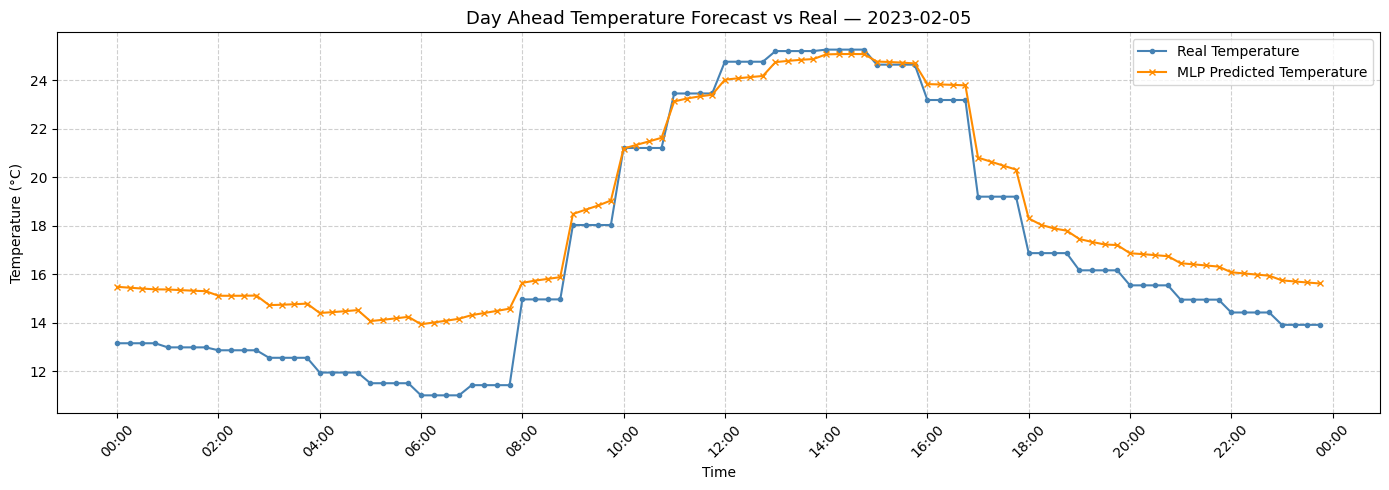

In [48]:
#evaluation mode
model.eval() 

# Pick a specific date
target_date = '2023-02-05' 

# Get the row indices for that date from the original dataframe
day_idx = df[df['DateTime'].str.startswith(target_date)].index.tolist()

# Extract and scale those rows
X_day = scaler_X.transform(df.iloc[day_idx, 2:].values)
y_day_actual = df.iloc[day_idx, 1].values  # raw actual temperatures

# Convert to tensor and predict
X_day_tensor = torch.from_numpy(X_day).float().to(device)

with torch.no_grad():
    preds_day = model(X_day_tensor).cpu().numpy()

# Inverse transform predictions back to real temperatures
preds_day_actual = scaler_y.inverse_transform(preds_day).flatten()

# Plot
time_index = pd.date_range(start='00:00', periods=len(preds_day_actual), freq='15min')

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(time_index,y_day_actual,    color='steelblue',  marker='o', markersize=3, linewidth=1.5, label='Real Temperature')
ax.plot(time_index, preds_day_actual, color='darkorange', marker='x', markersize=4, linewidth=1.5, label='MLP Predicted Temperature')

ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
ax.xaxis.set_major_locator(mdates.HourLocator(interval=2))
plt.xticks(rotation=45)
y_day_actual
# Metrics
mse  = mean_squared_error( y_day_actual, preds_day_actual)
rmse = np.sqrt(mse)
mae  = mean_absolute_error( y_day_actual, preds_day_actual)
r2   = r2_score( y_day_actual, preds_day_actual)
mape = np.mean(np.abs(( y_day_actual - preds_day_actual) /  y_day_actual)) * 100 

print(f'MSE:  {mse:.4f}')
print(f'RMSE: {rmse:.4f}')
print(f'MAE:  {mae:.4f}')
print(f'R²:   {r2:.4f}')
print(f'MAPE: {mape:.2f}%')

ax.set_title(f'Day Ahead Temperature Forecast vs Real — {target_date}', fontsize=13)
ax.set_xlabel('Time')
ax.set_ylabel('Temperature (°C)')
ax.legend()
ax.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

Model Evaluation

MSE:  0.0446
RMSE: 0.2111
MAE:  0.1667
R²:   0.9872
MAPE: 0.61%


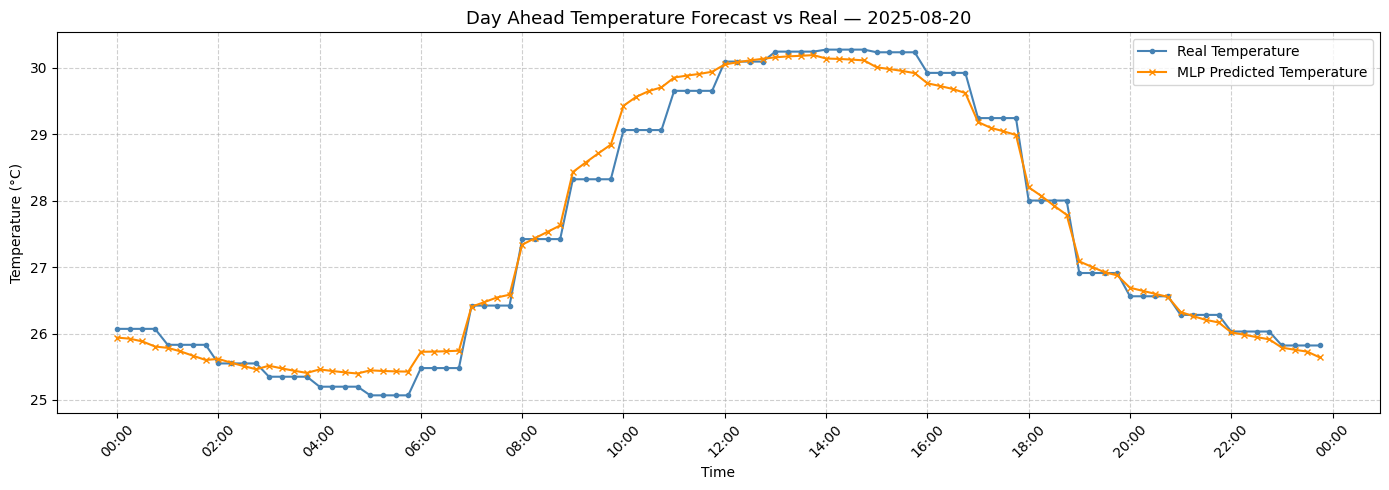

In [70]:
#evaluation mode
model.eval() 

# Pick a specific date
target_date = '2025-08-20' 

# Get the row indices for that date from the original dataframe
day_idx = df[df['DateTime'].str.startswith(target_date)].index.tolist()

# Extract and scale those rows
X_day = scaler_X.transform(df.iloc[day_idx, 2:].values)
y_day_actual = df.iloc[day_idx, 1].values  # raw actual temperatures

# Convert to tensor and predict
X_day_tensor = torch.from_numpy(X_day).float().to(device)

with torch.no_grad():
    preds_day = model(X_day_tensor).cpu().numpy()

# Inverse transform predictions back to real temperatures
preds_day_actual = scaler_y.inverse_transform(preds_day).flatten()

# Plot
time_index = pd.date_range(start='00:00', periods=len(preds_day_actual), freq='15min')

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(time_index,y_day_actual,    color='steelblue',  marker='o', markersize=3, linewidth=1.5, label='Real Temperature')
ax.plot(time_index, preds_day_actual, color='darkorange', marker='x', markersize=4, linewidth=1.5, label='MLP Predicted Temperature')

ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
ax.xaxis.set_major_locator(mdates.HourLocator(interval=2))
plt.xticks(rotation=45)
y_day_actual
# Metrics
mse  = mean_squared_error( y_day_actual, preds_day_actual)
rmse = np.sqrt(mse)
mae  = mean_absolute_error( y_day_actual, preds_day_actual)
r2   = r2_score( y_day_actual, preds_day_actual)
mape = np.mean(np.abs(( y_day_actual - preds_day_actual) /  y_day_actual)) * 100 

print(f'MSE:  {mse:.4f}')
print(f'RMSE: {rmse:.4f}')
print(f'MAE:  {mae:.4f}')
print(f'R²:   {r2:.4f}')
print(f'MAPE: {mape:.2f}%')

ax.set_title(f'Day Ahead Temperature Forecast vs Real — {target_date}', fontsize=13)
ax.set_xlabel('Time')
ax.set_ylabel('Temperature (°C)')
ax.legend()
ax.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [37]:
# Check exactly where training ends and test begins
train_end_idx = len(X_train)
print("Training ends at:", df.iloc[train_end_idx - 1]['DateTime'])
print("Test starts at:",   df.iloc[train_end_idx]['DateTime'])
print("Test ends at:",     df.iloc[-1]['DateTime'])

Training ends at: 2025-01-06 04:30:00
Test starts at: 2025-01-06 04:45:00
Test ends at: 2026-01-05 23:45:00


In [ ]:
def result(target_date):
    model.eval()
    # Get the row indices for that date from the original dataframe
    day_idx = df[df['DateTime'].str.startswith(target_date)].index.tolist()
    
    # Extract and scale those rows
    X_day = scaler_X.transform(df.iloc[day_idx, 2:].values)
    y_day_actual = df.iloc[day_idx, 1].values  # raw actual temperatures
    
    # Convert to tensor and predict
    X_day_tensor = torch.from_numpy(X_day).float().to(device)
    
    with torch.no_grad():
        preds_day = model(X_day_tensor).cpu().numpy()
    
    # Inverse transform predictions back to real temperatures
    preds_day_actual = scaler_y.inverse_transform(preds_day).flatten()
    
    # Metrics
    mse  = mean_squared_error( y_day_actual, preds_day_actual)
    rmse = np.sqrt(mse)
    mae  = mean_absolute_error( y_day_actual, preds_day_actual)
    r2   = r2_score( y_day_actual, preds_day_actual)
    mape = np.mean(np.abs(( y_day_actual - preds_day_actual) /  y_day_actual)) * 100 
    
    print(f'MSE:  {mse:.4f}')
    print(f'RMSE: {rmse:.4f}')
    print(f'MAE:  {mae:.4f}')
    print(f'R²:   {r2:.4f}')
    print(f'MAPE: {mape:.2f}%')
    
    return mse, mae, rmse, r2, mape

In [63]:
result('2025-11-25')

MSE:  1.6736
RMSE: 1.2937
MAE:  1.0857
R²:   0.8923
MAPE: 5.63%


(1.6736343753057266,
 1.085660270849864,
 np.float64(1.2936902161281605),
 0.8923444127101268,
 np.float64(5.634118767678987))

making a loop to determine test metrics value for all the days in the test set to plot a distribution curve of metrics to determine the maximum occuring metric across the test set

In [64]:
# Get test set dates only
train_end_idx = len(X_train)
test_dates = df.iloc[train_end_idx:]['DateTime'].str[:10].unique()

records = []
for date in test_dates:
    day_idx = df[df['DateTime'].str.startswith(date)].index.tolist()
    if len(day_idx) != 96:   # skip incomplete days
        continue
    mse, mae, rmse, r2, mape = result(date)
    records.append({'date': date, 'MSE': mse, 'MAE': mae, 'RMSE': rmse, 'R2': r2, 'MAPE': mape})

metrics_df = pd.DataFrame(records)
print(metrics_df.describe())

MSE:  3.2658
RMSE: 1.8071
MAE:  1.4448
R²:   0.8307
MAPE: 7.06%
MSE:  3.5129
RMSE: 1.8743
MAE:  1.4695
R²:   0.6915
MAPE: 8.84%
MSE:  23.4662
RMSE: 4.8442
MAE:  4.5925
R²:   -0.5038
MAPE: 40.73%
MSE:  3.9175
RMSE: 1.9793
MAE:  1.5970
R²:   0.8228
MAPE: 15.45%
MSE:  1.9071
RMSE: 1.3810
MAE:  1.0663
R²:   0.9113
MAPE: 9.62%
MSE:  1.5480
RMSE: 1.2442
MAE:  1.0861
R²:   0.9337
MAPE: 7.44%
MSE:  0.4967
RMSE: 0.7048
MAE:  0.5880
R²:   0.9699
MAPE: 3.68%
MSE:  1.5149
RMSE: 1.2308
MAE:  1.0510
R²:   0.9132
MAPE: 6.43%
MSE:  3.3425
RMSE: 1.8283
MAE:  1.5620
R²:   0.7980
MAPE: 10.58%
MSE:  1.7014
RMSE: 1.3044
MAE:  1.0742
R²:   0.9006
MAPE: 7.31%
MSE:  0.6307
RMSE: 0.7941
MAE:  0.6138
R²:   0.9530
MAPE: 3.87%
MSE:  2.1615
RMSE: 1.4702
MAE:  1.2011
R²:   0.8925
MAPE: 5.84%
MSE:  3.4290
RMSE: 1.8517
MAE:  1.6890
R²:   0.8153
MAPE: 11.12%
MSE:  4.7804
RMSE: 2.1864
MAE:  1.9290
R²:   0.8200
MAPE: 14.11%
MSE:  4.7261
RMSE: 2.1739
MAE:  1.8442
R²:   0.8019
MAPE: 13.80%
MSE:  2.1304
RMSE: 1.4596
MAE:  

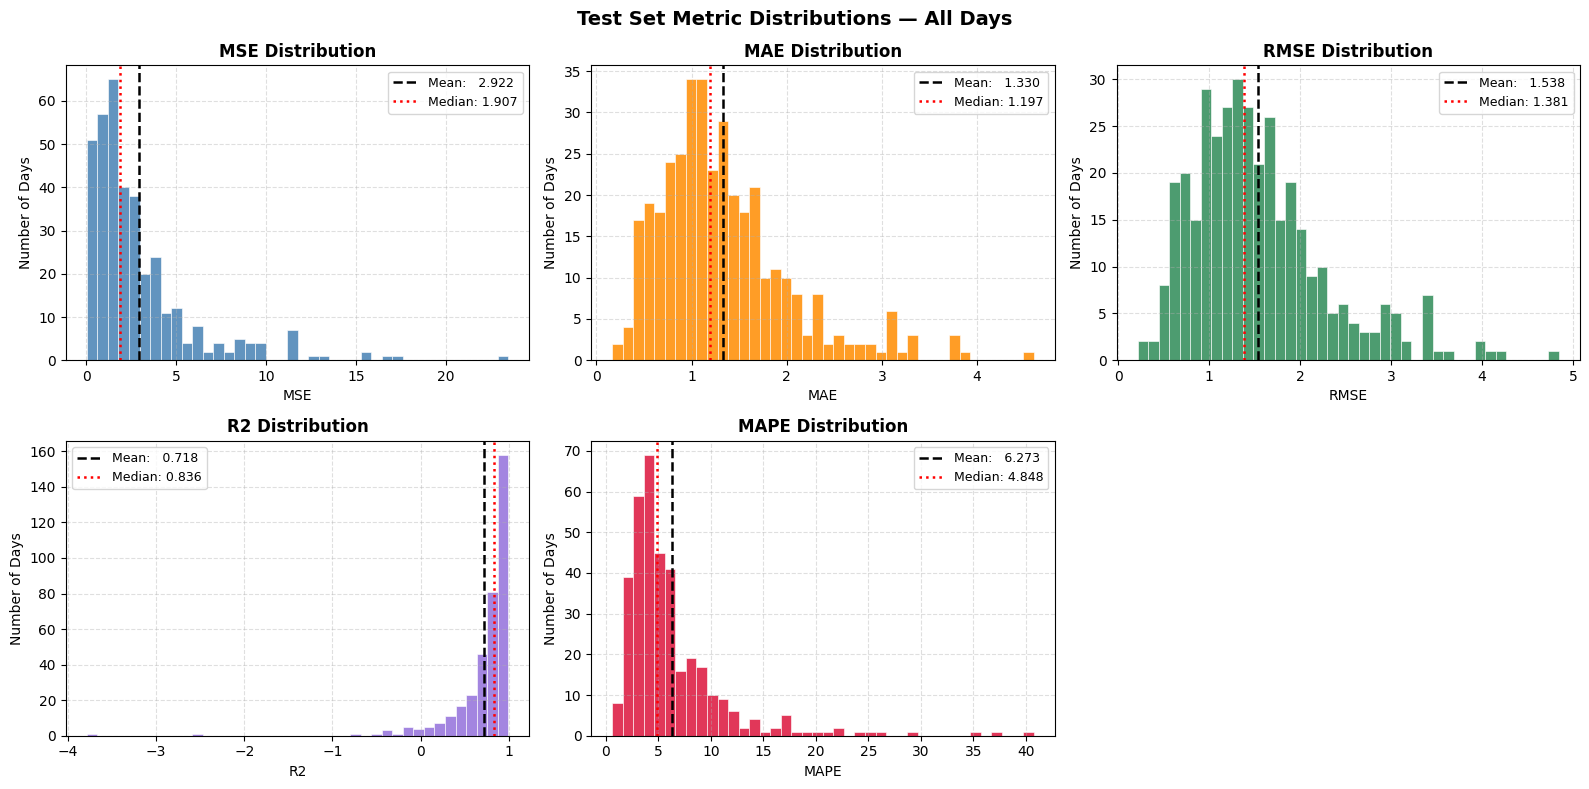

In [65]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

metrics = ['MSE', 'MAE', 'RMSE', 'R2', 'MAPE']
colors  = ['steelblue', 'darkorange', 'seagreen', 'mediumpurple', 'crimson']

for i, (metric, color) in enumerate(zip(metrics, colors)):
    ax = axes[i]
    data = metrics_df[metric]

    ax.hist(data, bins=40, color=color, edgecolor='white', linewidth=0.5, alpha=0.85)

    ax.axvline(data.mean(),   color='black',  linewidth=1.8, linestyle='--', label=f'Mean:   {data.mean():.3f}')
    ax.axvline(data.median(), color='red',    linewidth=1.8, linestyle=':',  label=f'Median: {data.median():.3f}')

    ax.set_title(f'{metric} Distribution', fontsize=12, fontweight='bold')
    ax.set_xlabel(metric)
    ax.set_ylabel('Number of Days')
    ax.legend(fontsize=9)
    ax.grid(True, linestyle='--', alpha=0.4)

# hide the 6th empty subplot
axes[-1].set_visible(False)

plt.suptitle('Test Set Metric Distributions — All Days', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()